# Лабораторная работа №3 Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

Панасюк Ксения ИУ5-64Б

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

Задание:

        Выберите набор данных (датасет) для решения задачи классификации или регрессии.
        В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
        С использованием метода train_test_split разделите выборку на обучающую и тестовую.
        Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
        Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
        Сравните метрики качества исходной и оптимальной моделей.

# 1) Импорты и загрузка датасета

Был выбран датасет рака груди

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Загрузка датасета
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Размер выборки: {df.shape}")
print(f"Целевые классы: {data.target_names}")

print(f"Пропуски: {df.isnull().sum()}")

categorical_columns = df.select_dtypes(include=['object']).columns
print(f"Категориальные признаки: {categorical_columns}")

Размер выборки: (569, 30)
Целевые классы: ['malignant' 'benign']
Пропуски: mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Категориальные признаки: Index([], dtype='

# 2) Масштабирование и разделение на выборки

In [10]:
print(df.describe().T[['min', 'max', 'mean']])

# Разделение на обучающую и тестовую (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.3, random_state=42, stratify=y
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

                                min         max        mean
mean radius                6.981000    28.11000   14.127292
mean texture               9.710000    39.28000   19.289649
mean perimeter            43.790000   188.50000   91.969033
mean area                143.500000  2501.00000  654.889104
mean smoothness            0.052630     0.16340    0.096360
mean compactness           0.019380     0.34540    0.104341
mean concavity             0.000000     0.42680    0.088799
mean concave points        0.000000     0.20120    0.048919
mean symmetry              0.106000     0.30400    0.181162
mean fractal dimension     0.049960     0.09744    0.062798
radius error               0.111500     2.87300    0.405172
texture error              0.360200     4.88500    1.216853
perimeter error            0.757000    21.98000    2.866059
area error                 6.802000   542.20000   40.337079
smoothness error           0.001713     0.03113    0.007041
compactness error          0.002252     

# 3) Обучение базовой модели
Возьмем произвольное значение K=3

In [12]:
knn_base = KNeighborsClassifier(n_neighbors=3)
knn_base.fit(X_train_scaled, y_train)

base_preds = knn_base.predict(X_test_scaled)
base_accuracy = accuracy_score(y_test, base_preds)

print("--- Базовая модель (K=3) ---")
print(f"Accuracy: {base_accuracy:.4f}")
print(classification_report(y_test, base_preds, target_names=data.target_names))

--- Базовая модель (K=3) ---
Accuracy: 0.9532
              precision    recall  f1-score   support

   malignant       1.00      0.88      0.93        64
      benign       0.93      1.00      0.96       107

    accuracy                           0.95       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.95      0.95       171



# 4) Подбор гиперпараметров с кросс-валидацией

In [13]:
# Использование GridSearchCV (K-Fold)
# Диапазон K от 1 до 25
parameters = {'n_neighbors': np.arange(1, 26)}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(KNeighborsClassifier(), parameters, cv=kf, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшее K (GridSearch): {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

Лучшее K (GridSearch): {'n_neighbors': np.int64(5)}
Лучшая точность на кросс-валидации: 0.9673


In [14]:
# Использование RandomizedSearchCV (Stratified K-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    KNeighborsClassifier(), 
    param_distributions=parameters, 
    n_iter=15, 
    cv=skf, 
    scoring='accuracy', 
    random_state=42
)
random_search.fit(X_train_scaled, y_train)

print(f"Лучшее K (RandomSearch): {random_search.best_params_}")

Лучшее K (RandomSearch): {'n_neighbors': np.int64(4)}


--- Итоговое сравнение ---
Точность исходной модели (K=3): 0.9532
Точность оптимальной модели (K=5): 0.9591


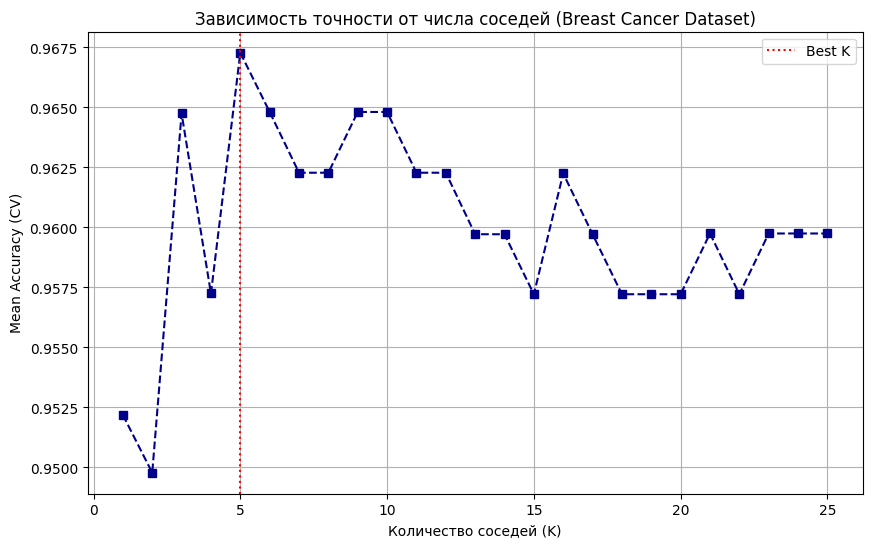

In [15]:
# Оценка лучшей модели на тестовой выборке
best_knn = grid_search.best_estimator_
opt_preds = best_knn.predict(X_test_scaled)
opt_accuracy = accuracy_score(y_test, opt_preds)

print("--- Итоговое сравнение ---")
print(f"Точность исходной модели (K=3): {base_accuracy:.4f}")
print(f"Точность оптимальной модели (K={grid_search.best_params_['n_neighbors']}): {opt_accuracy:.4f}")

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(parameters['n_neighbors'], grid_search.cv_results_['mean_test_score'], 
         marker='s', linestyle='--', color='darkblue')
plt.axvline(grid_search.best_params_['n_neighbors'], color='red', linestyle=':', label='Best K')
plt.title('Зависимость точности от числа соседей (Breast Cancer Dataset)')
plt.xlabel('Количество соседей (K)')
plt.ylabel('Mean Accuracy (CV)')
plt.legend()
plt.grid(True)
plt.show()